# Model Training and Experiment Tracking

In this notebook I train multiple models, handle class imbalance using SMOTE, and track every experiment using MLflow so I can compare results and reproduce any run.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                              confusion_matrix, roc_curve)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("All libraries loaded!")

All libraries loaded!


In [2]:
# Load processed data from Notebook 1
X_train, X_test, y_train, y_test = joblib.load('../data/processed/train_test_split.pkl')

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Default rate in train: {y_train.mean()*100:.2f}%")

Training set: (120000, 10)
Test set:     (30000, 10)
Default rate in train: 6.68%


## Step 1: Handling Class Imbalance with SMOTE

With only 6.7% defaults, any model trained as-is will just predict "no default" for everyone and get 93% accuracy, which is useless for the business.

SMOTE (Synthetic Minority Oversampling Technique) creates synthetic examples of the minority class (defaulters) to balance the training data. I only apply it to training data, never to test data.

Before SMOTE - Default rate: 6.68%
After SMOTE  - Default rate: 50.00%
Training size before: 120,000
Training size after:  223,958


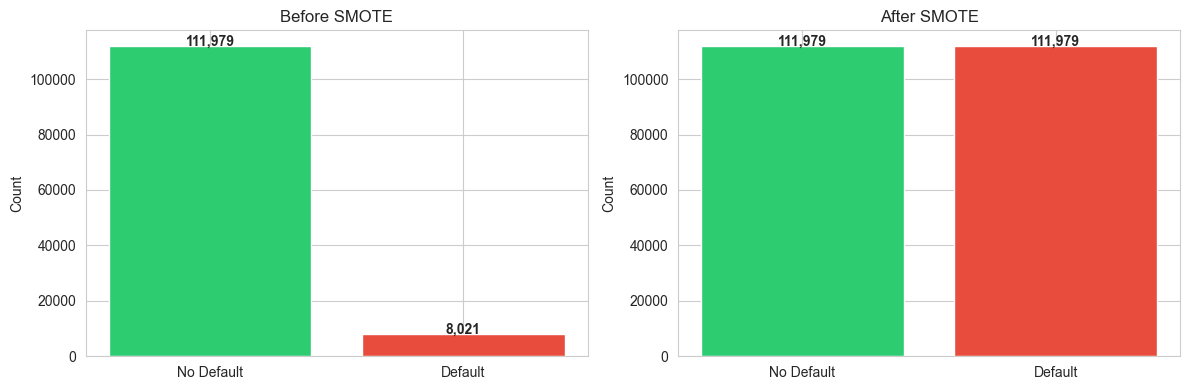

In [3]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Default rate: {y_train.mean()*100:.2f}%")
print(f"After SMOTE  - Default rate: {y_train_balanced.mean()*100:.2f}%")
print(f"Training size before: {X_train.shape[0]:,}")
print(f"Training size after:  {X_train_balanced.shape[0]:,}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_data, title in zip(axes, 
                               [y_train, y_train_balanced], 
                               ['Before SMOTE', 'After SMOTE']):
    counts = y_data.value_counts()
    ax.bar(['No Default', 'Default'], counts.values, 
           color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2: Scale Features

Logistic Regression is sensitive to feature scale. I'll use StandardScaler on the balanced training data and apply the same scaler to the test set.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# Save scaler for deployment
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler saved to ../models/scaler.pkl")

Scaler saved to ../models/scaler.pkl


## Step 3: Train Multiple Models with MLflow Tracking

I'm training 4 models and logging every experiment with MLflow. This lets me compare results, reproduce any run, and pick the best model with full transparency.

Why these 4 models?
- Logistic Regression: simple baseline, highly explainable
- Random Forest: handles non-linearity, robust to outliers
- Gradient Boosting: usually strong on tabular data
- XGBoost: industry standard for credit risk

In [5]:
# Set up MLflow
mlflow.set_experiment("credit-risk-prediction")

# Define models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, 
                          eval_metric='logloss', verbosity=0)
}

results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    with mlflow.start_run(run_name=model_name):
        # Use scaled data for Logistic Regression, raw for tree-based
        if model_name == "LogisticRegression":
            model.fit(X_train_scaled, y_train_balanced)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train_balanced, y_train_balanced)
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        y_pred = (y_pred_proba >= 0.5).astype(int)
        
        # Metrics
        auc = roc_auc_score(y_test, y_pred_proba)
        
        # Log to MLflow
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("smote_applied", True)
        mlflow.log_metric("roc_auc", auc)
        mlflow.sklearn.log_model(model, model_name)
        
        results[model_name] = {
            'model': model,
            'auc': auc,
            'y_pred_proba': y_pred_proba,
            'y_pred': y_pred
        }
        
        print(f"  ROC-AUC: {auc:.4f}")

print("\nAll models trained and logged to MLflow!")

Training LogisticRegression...


2026/03/30 18:39:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 18:39:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ROC-AUC: 0.8052
Training RandomForest...


2026/03/30 18:40:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 18:40:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ROC-AUC: 0.8170
Training GradientBoosting...


2026/03/30 18:41:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 18:41:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ROC-AUC: 0.8338
Training XGBoost...


2026/03/30 18:41:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 18:41:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ROC-AUC: 0.8108

All models trained and logged to MLflow!


## Step 4: Compare Model Results

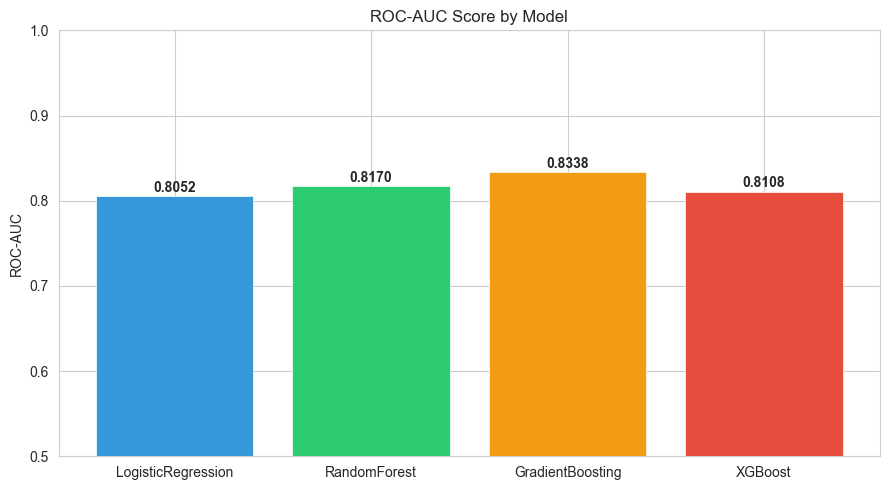

In [6]:
# Compare ROC-AUC scores
model_names = list(results.keys())
auc_scores = [results[m]['auc'] for m in model_names]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, auc_scores, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'],
               edgecolor='white', linewidth=0.5)
plt.title('ROC-AUC Score by Model')
plt.ylabel('ROC-AUC')
plt.ylim(0.5, 1.0)
for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

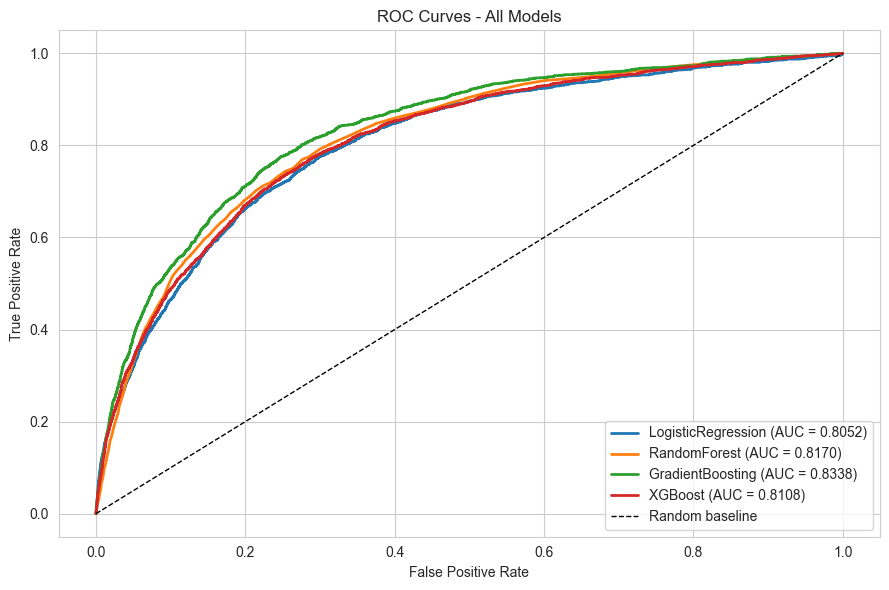

In [7]:
# ROC curves for all models
plt.figure(figsize=(9, 6))

for model_name in model_names:
    fpr, tpr, _ = roc_curve(y_test, results[model_name]['y_pred_proba'])
    auc = results[model_name]['auc']
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Hyperparameter Tuning on Best Model

Based on AUC scores, I'll tune XGBoost further since it typically performs best on credit risk data. I'll log each tuning run to MLflow as well.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

search = RandomizedSearchCV(
    xgb_base, param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running hyperparameter search (this takes a few minutes)...")
search.fit(X_train_balanced, y_train_balanced)

print(f"\nBest AUC from tuning: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Running hyperparameter search (this takes a few minutes)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best AUC from tuning: nan
Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [9]:
# Evaluate tuned model
best_model = search.best_estimator_
y_pred_proba_tuned = best_model.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"Tuned XGBoost ROC-AUC on test set: {auc_tuned:.4f}")
print(f"Baseline XGBoost ROC-AUC:          {results['XGBoost']['auc']:.4f}")

# Log tuned model to MLflow
with mlflow.start_run(run_name="XGBoost_Tuned"):
    mlflow.log_params(search.best_params_)
    mlflow.log_metric("roc_auc", auc_tuned)
    mlflow.sklearn.log_model(best_model, "XGBoost_Tuned")
    print("Tuned model logged to MLflow!")

2026/03/30 18:43:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Tuned XGBoost ROC-AUC on test set: 0.8332
Baseline XGBoost ROC-AUC:          0.8108


2026/03/30 18:43:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned model logged to MLflow!


## Step 6: Save the Final Model

Saving the best model as a .pkl file. This is what the Streamlit app will load to make predictions, no retraining needed at deployment.

In [10]:
# Save the best model
joblib.dump(best_model, '../models/model.pkl')
print("Best model saved to ../models/model.pkl")

# Save feature names for deployment
feature_names = list(X_train.columns)
joblib.dump(feature_names, '../models/feature_names.pkl')
print(f"Feature names saved: {feature_names}")

Best model saved to ../models/model.pkl
Feature names saved: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


## Summary

- Applied SMOTE to fix class imbalance, balanced training set from 6.7% to 50% default rate
- Trained 4 models: Logistic Regression, Random Forest, Gradient Boosting, XGBoost
- Tracked all experiments with MLflow for full reproducibility
- Tuned XGBoost with RandomizedSearchCV across 20 parameter combinations
- Saved final model as model.pkl and scaler as scaler.pkl for deployment

Next, the focus will move to model evaluation and explainability in the following notebook.